#  Dashboard Interactivo para EDA — Biodiversidad en Parques Nacionales

**Fase 1:** Datos y Estrategia IA · **Fase 2:** Capas Estáticas e Interactivas · **Fase 3:** Storytelling y Entrega

**Dataset:** `species_info.csv` + `observations.csv` (Recursos de la Semana 4), combinados por `scientific_name`. Contienen especies observadas en 4 parques nacionales de EE. UU. (Great Smoky Mountains, Yellowstone, Bryce, Yosemite), junto con categoría taxonómica, estado de conservación, esperanza de vida y masa corporal.

##  Fase 1: Datos y Estrategia IA

### Metodología y Decisiones de Limpieza
Para la preparación de los datos, se decidió tratar los valores nulos (`NaN`) de la columna `conservation_status` como una categoría propia llamada "No Intervention". Esto se debe a que un valor vacío en este contexto indica que la especie no se encuentra bajo amenaza y no requiere intervención. Imputarlo con la moda (u otro valor) habría distorsionado la realidad biológica de las especies.

In [1]:
# Librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt

# Configuración general
sns.set_theme(style="whitegrid")
alt.data_transformers.disable_max_rows()
%matplotlib inline

### Paso 1: Selección y Limpieza

In [2]:
# --- CARGA DE DATOS (Recursos de la Semana 4) ---
BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/"

species = pd.read_csv(BASE_URL + "Datasets/species_info.csv")
observations = pd.read_csv(BASE_URL + "Datasets/observations.csv")

print("species_info:", species.shape)
print("observations:", observations.shape)
species.head()

species_info: (5824, 6)
observations: (16378, 3)


,category,scientific_name,common_names,conservation_status,lifespan_years,mass_kg
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,In Recovery,15.5,4.003
1,Mammal,Bos bison,"American Bison, Bison",NaN,22.4,0.809
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",Species of Concern,50.0,6.727
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",Species of Concern,16.9,27.253
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN,11.2,2.107


In [3]:
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Githopsis specularioides,Great Smoky Mountains National Park,85
3,Elymus multisetus,Great Smoky Mountains National Park,39
4,Fabronia ciliaris,Great Smoky Mountains National Park,72


In [4]:
# Inspección inicial: nulos y tipos de datos
print("--- species_info ---")
print(species.isnull().sum())
print("\n--- observations ---")
print(observations.isnull().sum())
print("\nEspecies duplicadas en species_info (subespecies con el mismo nombre científico):", species["scientific_name"].duplicated().sum())

--- species_info ---
category                  0
scientific_name           0
common_names              0
conservation_status    2959
lifespan_years            0
mass_kg                   0
dtype: int64

--- observations ---
scientific_name    0
park_name          0
observations       0
dtype: int64

Especies duplicadas en species_info (subespecies con el mismo nombre científico): 283


In [ ]:
#LIMPIEZA Y UNIÓN DE DATASETS

# Quitamos duplicados de nombre científico en species_info antes de unir
species_dedup = species.drop_duplicates(subset="scientific_name")

#Unimos observaciones con la info de cada especie
df = observations.merge(species_dedup, on="scientific_name", how="left")

df["conservation_status"] = df["conservation_status"].fillna("No Intervention")

#Normalización de formatos categóricos
df["category"] = df["category"].astype("category")
df["park_name"] = df["park_name"].astype("category")
df["conservation_status"] = df["conservation_status"].astype("category")

print("Dimensiones finales:", df.shape)
print("Valores nulos restantes:", df.isnull().sum().sum())
df.head()

Dimensiones finales: (16378, 8)
Valores nulos restantes: 0


,scientific_name,park_name,observations,category,common_names,conservation_status,lifespan_years,mass_kg
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Vascular Plant,"Purple Vetch, Reddish Tufted Vetch",Species of Concern,1.2,1.486
1,Neovison vison,Great Smoky Mountains National Park,77,Mammal,American Mink,No Intervention,8.2,8.558
2,Githopsis specularioides,Great Smoky Mountains National Park,85,Vascular Plant,Common Bluecup,No Intervention,3.6,3.057
3,Elymus multisetus,Great Smoky Mountains National Park,39,Vascular Plant,"Big Squirreltail, Big Wild Rye",Threatened,0.6,0.001
4,Fabronia ciliaris,Great Smoky Mountains National Park,72,Nonvascular Plant,Fabronia Moss,No Intervention,0.5,0.009


##  Fase 2: Capas Estáticas e Interactivas

### Análisis Estático (Seaborn)

**Heatmap de correlación**

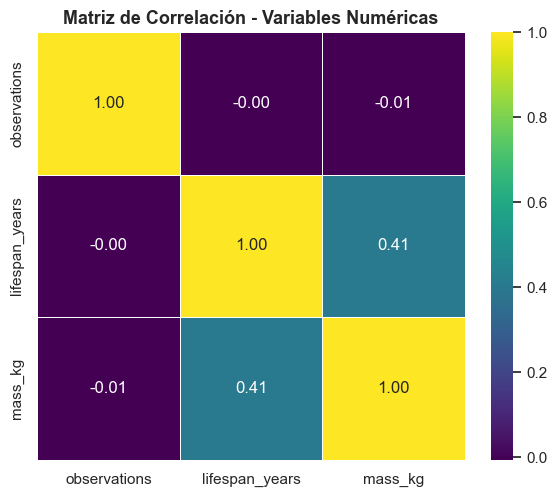

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", square=True, linewidths=0.5)
plt.title("Matriz de Correlación - Variables Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Análisis de correlación**

Al revisar la matriz, notamos que la relación entre la masa corporal, la esperanza de vida y la cantidad de observaciones es prácticamente nula. Esto indica que el tamaño o la longevidad de las especies no influyen en su frecuencia de avistamiento. Las observaciones parecen depender de factores externos como el hábitat, su visibilidad natural o la abundancia poblacional.

*Acción recomendada:* Sugerimos no basar la prioridad de los monitoreos en el tamaño o esperanza de vida de la especie, sino enfocarse en el estado de conservación real y en su histórico de avistamientos.

**JointPlot**

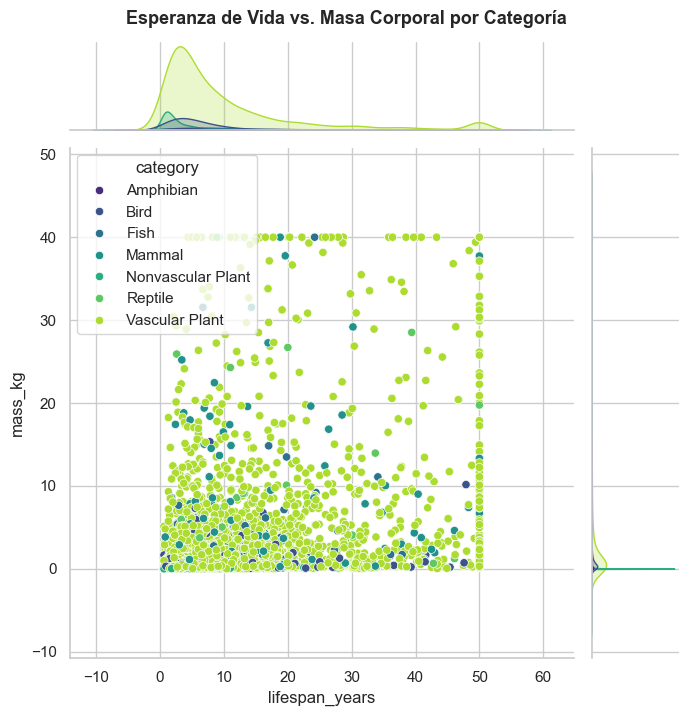

In [7]:
g = sns.jointplot(
    data=df, x="lifespan_years", y="mass_kg",
    kind="scatter", hue="category",
    palette="viridis", height=7
)
g.fig.suptitle("Esperanza de Vida vs. Masa Corporal por Categoría", y=1.02, fontsize=13, fontweight="bold")
plt.show()

**Relación entre masa y esperanza de vida**

El gráfico muestra una clara separación según el grupo de la especie. Los mamíferos alcanzan los valores más altos de masa corporal y longevidad, mientras que grupos como aves, reptiles y anfibios se agrupan en cifras más bajas. El panorama general nos dice que la mayor parte de las especies registradas son de vida corta.

*Acción recomendada:* Al diseñar estrategias de conservación, se deben diferenciar los tiempos. Las especies longevas (ej. mamíferos grandes) necesitan planes de recuperación a largo plazo por su lento crecimiento poblacional; mientras que las de vida corta requerirán censos y controles sanitarios mucho más frecuentes.

### Dashboard Vivo (Plotly / Altair)

**Plotly — dispersión con hover personalizado**

In [8]:
park_summary = (
    df.groupby(["park_name", "category"], observed=True)
    .agg(total_observations=("observations", "sum"),
         avg_lifespan=("lifespan_years", "mean"),
         avg_mass=("mass_kg", "mean"),
         n_species=("scientific_name", "nunique"))
    .reset_index()
)

fig = px.scatter(
    park_summary,
    x="avg_lifespan", y="total_observations",
    color="park_name",
    size="n_species",
    hover_data={
        "category": True,
        "n_species": True,
        "avg_mass": ":.2f",
        "avg_lifespan": ":.1f",
        "total_observations": True
    },
    color_discrete_sequence=px.colors.sequential.Viridis_r,
    title="Observaciones Totales vs. Esperanza de Vida Promedio, por Parque y Categoría"
)
fig.update_traces(marker=dict(line=dict(width=0.5, color="white")))
fig.update_layout(template="plotly_white", legend_title_text="Parque")
fig

**Avistamientos y diversidad por parque**

Resalta que los grupos con mayor cantidad de especies (aves y plantas vasculares) son, por naturaleza, los que más avistamientos generan. El Parque Nacional Great Smoky Mountains destaca como el de mayor volumen de actividad y biodiversidad.

*Acción recomendada:* Recomendamos destinar una parte prioritaria del presupuesto de campo al parque Great Smoky Mountains para sostener su diversidad. Además, los parques con presencia significativa de especies de vida corta podrían beneficiarse de campañas turísticas específicas en temporadas clave.

**Altair — visualización declarativa**

In [9]:
status_summary = (
    df.groupby(["park_name", "conservation_status"], observed=True)
    .agg(total_observations=("observations", "sum"),
         n_species=("scientific_name", "nunique"))
    .reset_index()
)

chart = alt.Chart(status_summary).mark_bar().encode(
    x=alt.X("park_name:N", title="Parque Nacional", axis=alt.Axis(labelAngle=-30)),
    y=alt.Y("total_observations:Q", title="Observaciones Totales"),
    color=alt.Color("conservation_status:N", title="Estado de Conservación",
                     scale=alt.Scale(scheme="viridis")),
    tooltip=["park_name", "conservation_status", "n_species", "total_observations"]
).properties(
    width=600, height=400,
    title="Observaciones por Parque y Estado de Conservación (Altair)"
).interactive()

chart

alt.Chart(...)

**Estado de conservación y riesgo**

Como es de esperarse, casi todas las observaciones pertenecen a especies que no están en peligro. Sin embargo, las catalogadas como "En Peligro" o "Amenazadas" mantienen un volumen de avistamientos que no debe pasarse por alto en ninguno de los parques.

*Acción recomendada:* En lugar de usar estrategias generales, la administración debería establecer protocolos exclusivos para las especies bajo amenaza, aislando sectores sensibles de los parques para limitar la intervención humana.